In [1]:
!pip install transformers accelerate rouge_score sacremoses torchvision

import os
import re
import random
import logging 
import warnings
from pathlib import Path
import concurrent.futures
from functools import partial
import shutil
from tqdm import tqdm
import multiprocessing
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from rouge_score import rouge_scorer
import torchvision.models as tv_models
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    GPT2Tokenizer, GPT2Config, GPT2Model, GPT2LMHeadModel
)

warnings.filterwarnings('ignore')
logging.getLogger("transformers").setLevel(logging.ERROR)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in uso: {device}")

# ----------------------------------------------------------
# ------------------ VARIABILI IMPORTANTI ------------------
# ----------------------------------------------------------

Kaggle = True
typeOfClassification = "multiclass"  # "binary" o "ternary" o "multiclass"

TRAIN_MAIN_MODEL = True   # funziona un po' a cazzo  -  Se True, allena il modello principale; se False, carica il modello già salvato
TRAIN_VAE = True          # funziona un po' a cazzo  -  Se True, allena il VAE; se False, carica il VAE già salvato
MODEL_SAVE_DIR = "./saved_model"
MAIN_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "model.pth")
VAE_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "vae.pth")

IMAGE_RESIZE= 384

TRAINING_SET_SIZE = 0.6
VALIDATION_SET_SIZE = 0.2
TEST_SET_SIZE = 0.2

BATCH_SIZE_DATALOADERS = 2

# ----------------- AZIONI DA FARE -----------------
# IMPOSTA TUTTO A TRUE PER ESEGUIRE TUTTO
CLEAN_DATASET = True
RECONSTRUCT_IMAGES = True
# -----------------------------------------


# ----------------- MAIN -----------------
NUM_EPOCHS_MAIN_MODEL = 20
LEARNING_RATE = 1e-4
EARLY_STOPPING_PATIENCE = 3

WEIGHT_DECAY = 1e-4
TEACHER_FORCING_RATE = 0.6

ALPHA_MAIN_MODEL = 0.5 # peso della loss di gpt-2
BETA_VAE = 0.6 # peso della loss del vae

FOCAL_LOSS = False if typeOfClassification.lower() == "binary" else True
FOCAL_LOSS = True
# -----------------------------------------
# ------------------ VAE ------------------
NUM_EPOCHS_VAE = 10
LEARNING_RATE_VAE = 5e-5
EARLY_STOPPING_PATIENCE_VAE = 3

ENCODER_VAE_TRAINABLE_LAYERS = 6
LATENT_DIM_VAE = 512
# -----------------------------------------

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

transform = transforms.Compose([
    transforms.Resize((IMAGE_RESIZE, IMAGE_RESIZE)),
    transforms.ToTensor(),
])



if(Kaggle):
    # PROJECTIONS_PATH = '/kaggle/input/chest-xrays-indiana-university/indiana_projections.csv'
    # REPORTS_PATH = '/kaggle/input/chest-xrays-indiana-university/indiana_reports.csv'
    # IMG_DIR = '/kaggle/input/chest-xrays-indiana-university/images/images_normalized'

    # Kaggle funziona a cazzo, se questi path non vi funzionano commentateli e decommentate questi sotto
    
    PROJECTIONS_PATH = '/kaggle/input/indiana_projections.csv'
    REPORTS_PATH = '/kaggle/input/indiana_reports.csv'
    IMG_DIR = '/kaggle/input/images/images_normalized'
    
    REPORTS_OUTPUT_PATH = '/kaggle/working/indiana_reports_cleaned.csv'
    PROJECTIONS_OUTPUT_PATH = '/kaggle/working/indiana_projections_cleaned.csv'
    DISCARDED_DIR = '/kaggle/working/dataset/discarded'


print(f"Directory dei report: {REPORTS_PATH}")
print(f"Directory delle proiezioni: {PROJECTIONS_PATH}")
print(f"Directory delle immagini: {IMG_DIR}")
print(f"Directory delle immagini scartate: {DISCARDED_DIR}")


cpu_count = multiprocessing.cpu_count()
cpus_to_use = cpu_count - 1 if cpu_count > 1 else 1
print(f"Num workers: {cpus_to_use}")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 13.1 MB/s eta 0:00:00 0:00:01
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=9930571c275ef590d0e0d25cfa4140c54049081e735c506e732571ad198a5f9c
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score
Device in uso: cuda


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Directory dei report: /kaggle/input/indiana_reports.csv
Directory delle proiezioni: /kaggle/input/indiana_projections.csv
Directory delle immagini: /kaggle/input/images/images_normalized
Directory delle immagini scartate: /kaggle/working/dataset/discarded
Num workers: 3


# 1

In [2]:
if CLEAN_DATASET:

    def identifica_uid_sbagliati(initial_uids, valid_uids):
        return initial_uids - valid_uids

    def leggi_csv(path):
        try:
            return pd.read_csv(path)
        except Exception as e:
            logging.error(f"Errore nel caricamento del CSV {path}: {e}")
            return None

    def valida_projections(row, valid_projections):
        return (
            pd.notna(row['filename']) and 
            pd.notna(row['projection']) and 
            row['projection'] in valid_projections
        )

    def filtra_uid_con_2_foto(projections_df, images_dir):
        if not isinstance(images_dir, Path):
            images_dir = Path(images_dir)
        
        projection_counts = projections_df.groupby(['uid', 'projection']).size().unstack(fill_value=0)
        
        candidate_uids = projection_counts[
            (projection_counts.get('Frontal', 0) == 1) & 
            (projection_counts.get('Lateral', 0) == 1)
            ].index
        
        all_image_files = set(f.name for f in images_dir.glob("*.dcm.png"))
        valid_uids = set()
        
        for uid in candidate_uids:
            uid_rows = projections_df[projections_df['uid'] == uid]
            projection_files = uid_rows['filename'].tolist()
            
            if all(filename in all_image_files for filename in projection_files):
                uid_image_files = set(f.name for f in images_dir.glob(f"{uid}_*.dcm.png"))
                if uid_image_files == set(projection_files):
                    valid_uids.add(uid)
        
        return valid_uids

    def rimuovi_immagini(image_path_str):
        image_path = Path(image_path_str)
        try:
            if image_path.exists():
                image_path.unlink()
                logging.info(f"Rimosso immagine: {image_path.name}")
        except Exception as e:
            logging.error(f"Errore nella rimozione dell'immagine {image_path.name}: {e}")

    def muovi_immagini(image_path_str, dest_dir_str):
        src_path = Path(image_path_str)
        dest_dir = Path(dest_dir_str)
        try:
            if src_path.exists():
                dest_path = dest_dir / src_path.name
                shutil.move(str(src_path), str(dest_path))
                logging.info(f"Spostata immagine: {src_path.name} -> {dest_path}")
        except Exception as e:
            logging.error(f"Errore nello spostamento dell'immagine {src_path.name}: {e}")

    def conta_immagini_rimanenti(images_dir):
        if not isinstance(images_dir, Path):
            images_dir = Path(images_dir)
        if images_dir.exists():
            return len(list(images_dir.glob("*.dcm.png")))
        else:
            logging.warning(f"Directory delle immagini {images_dir} non esiste.")
            return 0

    def raccogli_immagini_da_processare(images_dir, invalid_uids, final_projections_df):
        if not isinstance(images_dir, Path):
            images_dir = Path(images_dir)
        images_to_process = []
        if images_dir.exists():
            for uid in invalid_uids:
                images = images_dir.glob(f"{uid}_*.dcm.png")
                images_to_process.extend(str(img) for img in images)
            expected_images = set(final_projections_df['filename'])
            all_image_files = set(f.name for f in images_dir.glob("*.dcm.png"))
            extra_images = all_image_files - expected_images
            images_to_process.extend(str(images_dir / img) for img in extra_images)
            images_to_process = list(set(images_to_process))
        else:
            logging.warning(f"La directory {images_dir} non esiste.")
        logging.info(f"Totale immagini da scartare/spostare: {len(images_to_process)}")
        return images_to_process

    def prepara_directory_discard(action, discarded_dir, images_dir):
        if not isinstance(images_dir, Path):
            images_dir = Path(images_dir)
        if action == "DISCARD":
            if not discarded_dir:
                discarded_dir = images_dir.parent / "discarded"
            else:
                discarded_dir = Path(discarded_dir)
            discarded_dir.mkdir(parents=True, exist_ok=True)
        return discarded_dir

    def remove_image(image_path_str):
        rimuovi_immagini(image_path_str)

    def move_image(image_path_str, dest_dir_str):
        muovi_immagini(image_path_str, dest_dir_str)

    def esegui_operazioni_sulle_immagini(images_to_process, action, discarded_dir, num_workers=None):
        if images_to_process:
            if action == "CLEAN":
                operation_func = remove_image
                logging.info("Rimozione fisica delle immagini scartate...")
            else:  # DISCARD
                operation_func = partial(move_image, dest_dir_str=str(discarded_dir))
                logging.info("Spostamento immagini scartate nella cartella 'discarded'...")
            with concurrent.futures.ThreadPoolExecutor(max_workers=num_workers) as executor:
                list(tqdm(executor.map(operation_func, images_to_process), total=len(images_to_process)))

    def save_final_csvs(final_reports_df, final_projections_df, reports_output_path, projections_output_path):
        try:
            final_reports_df.to_csv(reports_output_path, index=False)
            final_projections_df.to_csv(projections_output_path, index=False)
            logging.info("Salvati CSV con i record validi.")
        except Exception as e:
            logging.error(f"Errore nel salvataggio dei CSV finali: {e}")

    def create_discard_csvs(reports_df, projections_df, valid_uids, discard_output_dir, reports_path, projections_path):
        discard_output_dir = Path(discard_output_dir)
        discard_output_dir.mkdir(parents=True, exist_ok=True)
        discard_reports_path = discard_output_dir / f"Discard_{Path(reports_path).name}"
        discard_projections_path = discard_output_dir / f"Discard_{Path(projections_path).name}"
        invalid_reports_df = reports_df[~reports_df['uid'].isin(valid_uids)]
        invalid_projections_df = projections_df[~projections_df['uid'].isin(valid_uids)]
        invalid_reports_df.to_csv(discard_reports_path, index=False)
        invalid_projections_df.to_csv(discard_projections_path, index=False)
        logging.info("Generati i file CSV Discard_* con i record scartati.")

    def log_cleanup_summary(initial_reports, initial_projections, final_reports_df, final_projections_df, images_to_process, action):
        removed_reports = initial_reports - len(final_reports_df)
        removed_projections = initial_projections - len(final_projections_df)
        removed_images = len(images_to_process)
        logging.info("\n=== Riepilogo Pulizia ===")
        logging.info(f"Reports scartati (o spostati): {removed_reports}")
        logging.info(f"Projections scartati (o spostati): {removed_projections}")
        logging.info(f"Immagini scartate (o spostate): {removed_images}")

    def print_analyze_summary(removed_reports, removed_projections, removed_images):
        print(
            f"\nAnalisi completata.\n"
            f"Reports scartati: {removed_reports}\n"
            f"Projections scartati: {removed_projections}\n"
            f"Immagini scartate: {removed_images}"
        )

    def parse_and_filter_problems(row, problem_counts, threshold):
        problems_str = row["Problems"]
        mesh_str = row["MeSH"] if "MeSH" in row else ""
        if isinstance(problems_str, str) and problems_str.strip().lower() == "normal":
            return ["normal"]
        if isinstance(mesh_str, str) and mesh_str.strip().lower() == "normal":
            return ["normal"]
        if pd.isna(problems_str) or not problems_str.strip():
            return []
        splitted = [p.strip() for p in problems_str.split(';') if p.strip()]
        filtered = [p for p in splitted if problem_counts.get(p, 0) >= threshold]
        if len(filtered) > 1:
            filtered = [filtered[0]]
        return filtered

    def calcola_frequenze_problemi(valid_reports_df):
        problem_counts = {}
        for probs in valid_reports_df['Problems'].dropna():
            if probs.strip().lower() == "normal":
                continue
            for prob in probs.split(';'):
                prob = prob.strip()
                if prob:
                    problem_counts[prob] = problem_counts.get(prob, 0) + 1
        return problem_counts

    def cleanup_datasets(
        reports_path,
        projections_path,
        images_dir,
        discarded_dir,           
        reports_output_path,     
        projections_output_path, 
        action="ANALYZE",
        num_workers=None,
        random_seed=42,
        threshold=50
    ):
        logging.info("Inizio elaborazione del dataset...")
        logging.info(f"Modalità: {action}")
        if action not in ["ANALYZE", "CLEAN", "DISCARD"]:
            raise ValueError("action deve essere 'ANALYZE', 'CLEAN' o 'DISCARD'")
        random.seed(random_seed)
        if not isinstance(images_dir, Path):
            images_dir = Path(images_dir)
        essential_report_fields = ['MeSH', 'Problems', 'image', 'findings', 'impression']
        valid_projections_set = {'Frontal', 'Lateral'}
        
        logging.info("Caricamento dei CSV...")
        reports_df = leggi_csv(reports_path)
        projections_df = leggi_csv(projections_path)
        if reports_df is None or projections_df is None:
            logging.error("Errore nel caricamento dei CSV. Terminazione del processo.")
            return

        # Filtro per eliminare i record con "Technical Quality of Image Unsatisfactory"
        reports_df = reports_df[~reports_df['Problems'].str.contains("Technical Quality of Image Unsatisfactory", na=False)]
        
        initial_reports = len(reports_df)
        initial_projections = len(projections_df)
        all_uids_before = set(reports_df['uid'])
        logging.info(f"Record iniziali - Reports: {initial_reports}, Projections: {initial_projections}")

        # 1) Rimozione record reports con campi essenziali vuoti
        logging.info("Fase 1: Rimozione record reports con campi essenziali vuoti...")
        mask_notna = reports_df[essential_report_fields].notna().all(axis=1)
        mask_non_empty = (reports_df[essential_report_fields]
                        .apply(lambda x: x.astype(str).str.strip())
                        .ne('')).all(axis=1)
        valid_fields_mask = mask_notna & mask_non_empty
        valid_reports_df = reports_df[valid_fields_mask].copy()

        invalid_uids_due_to_essential_fields = set(reports_df.loc[~valid_fields_mask, 'uid'])
        projections_df = projections_df[~projections_df['uid'].isin(invalid_uids_due_to_essential_fields)].copy()
        logging.info(f"Reports validi (dopo campi essenziali): {len(valid_reports_df)}")
        logging.info(f"Projections rimanenti dopo rimozione UID invalidi: {len(projections_df)}")

        # 2) Rimozione record projections non validi
        logging.info("Fase 2: Rimozione record projections con campi vuoti/invalidi...")
        proj_mask = projections_df.apply(valida_projections, axis=1, args=(valid_projections_set,))
        valid_projections_df = projections_df[proj_mask].copy()
        invalid_uids_due_to_projections = set(projections_df.loc[~proj_mask, 'uid'])
        valid_reports_df = valid_reports_df[~valid_reports_df['uid'].isin(invalid_uids_due_to_projections)].copy()
        logging.info(f"Projections validi: {len(valid_projections_df)}")
        logging.info(f"Reports rimanenti dopo rimozione UID con proiezioni non valide: {len(valid_reports_df)}")

        # 3) Verifica 1 Frontal + 1 Laterale (prima passata) + presenza file immagine
        logging.info("Fase 3: Verifica 1 Frontal + 1 Laterale (prima passata)...")
        uids_with_2_proj = filtra_uid_con_2_foto(valid_projections_df, images_dir)
        valid_reports_df = valid_reports_df[valid_reports_df['uid'].isin(uids_with_2_proj)].copy()
        valid_projections_df = valid_projections_df[valid_projections_df['uid'].isin(uids_with_2_proj)].copy()
        logging.info(f"Reports dopo filtraggio 1 Frontal + 1 Laterale: {len(valid_reports_df)}")
        logging.info(f"Projections dopo filtraggio 1 Frontal + 1 Laterale: {len(valid_projections_df)}")

        # Raccolta degli UID validi finali
        final_uids = set(valid_reports_df['uid'])
        # Raccolta degli UID invalidi
        invalid_uids = identifica_uid_sbagliati(all_uids_before, final_uids)
        images_to_process = raccogli_immagini_da_processare(images_dir, invalid_uids, valid_projections_df)


        if action in ["CLEAN", "DISCARD"]:
            discarded_dir = prepara_directory_discard(action, discarded_dir, images_dir)
            esegui_operazioni_sulle_immagini(images_to_process, action, discarded_dir, num_workers)
            save_final_csvs(valid_reports_df, valid_projections_df, reports_output_path, projections_output_path)
            if action == "DISCARD":
                create_discard_csvs(reports_df, projections_df, final_uids, discarded_dir, reports_path, projections_path)
            remaining_images = conta_immagini_rimanenti(images_dir)
            logging.info(f"Immagini rimanenti in {images_dir}: {remaining_images}")
        else:
            logging.info("Modalità ANALYZE: nessuna modifica sul filesystem.")
            remaining_images = conta_immagini_rimanenti(images_dir)

        removed_reports = initial_reports - len(valid_reports_df)
        removed_projections = initial_projections - len(valid_projections_df)
        removed_images = len(images_to_process)
        
        log_cleanup_summary(initial_reports, initial_projections, valid_reports_df, valid_projections_df, images_to_process, action)
        
        print(f"\nnumero_di_projections: {len(valid_projections_df)}")
        print(f"numero_di_reports: {len(valid_reports_df)}")
        print(f"numero_di_immagini: {remaining_images}")

        if action == "ANALYZE":
            print_analyze_summary(removed_reports, removed_projections, removed_images)

    cleanup_datasets(
        reports_path=REPORTS_PATH,
        projections_path=PROJECTIONS_PATH,
        images_dir=IMG_DIR,
        discarded_dir=DISCARDED_DIR,
        reports_output_path=REPORTS_OUTPUT_PATH,
        projections_output_path=PROJECTIONS_OUTPUT_PATH,
        action="DISCARD",  # "ANALYZE" o "CLEAN" o "DISCARD"
        num_workers=cpus_to_use,
        random_seed=42,
        threshold=20
    )
    print("fine clean")


100%|██████████| 1896/1896 [00:18<00:00, 100.14it/s]


numero_di_projections: 5574
numero_di_reports: 2728
numero_di_immagini: 7470
fine clean


# 2

In [3]:
if not os.path.exists(PROJECTIONS_OUTPUT_PATH) or not os.path.exists(REPORTS_OUTPUT_PATH):
    raise FileNotFoundError("I file CSV cleaned non sono stati trovati. Assicurati di aver eseguito correttamente la cella di pulizia del dataset.")

logging.info("Fase 2: Creazione del DataFrame finale...")

df_image = pd.read_csv(PROJECTIONS_OUTPUT_PATH)
df_report = pd.read_csv(REPORTS_OUTPUT_PATH)

df_report = df_report[~df_report['Problems'].str.contains("Technical Quality of Image Unsatisfactory", na=False)]

unique_problems = set()
for problems in df_report['Problems'].dropna():
    for problem in problems.split(';'):
        unique_problems.add(problem.strip())
unique_problems = sorted(unique_problems)

print("\nElenco dei problemi unici nel dataset:")
for problem in unique_problems:
    print(f"- {problem}")

df = pd.DataFrame({'front_img': [], 'lateral_img': [], ' captions': [], 'problems': []})

common_uids = set(df_image['uid']).intersection(set(df_report['uid']))
for uid in common_uids:
    front_image = df_image.loc[(df_image['uid'] == uid) & (df_image['projection'] == 'Frontal')]
    lateral_img = df_image.loc[(df_image['uid'] == uid) & (df_image['projection'] == 'Lateral')]
    report_rows = df_report.loc[df_report['uid'] == uid]
    
    if not front_image.empty and not lateral_img.empty and not report_rows.empty:
        caption = report_rows['findings'].values[0]
        problems = report_rows['Problems'].values[0]
        
        df = pd.concat([df, pd.DataFrame([{
            'front_img': front_image.iloc[0]['filename'],
            'lateral_img': lateral_img.iloc[0]['filename'],
            'captions': caption,
            'problems': problems
        }])], axis=0)

df['front_img'] = IMG_DIR + '/' + df['front_img']
df['lateral_img'] = IMG_DIR + '/' + df['lateral_img']

df = df.reset_index(drop=True)
print("\nEcco una parte del DataFrame finale dopo la pulizia:")
print(df.head(10)) 
print(f"Dimensioni finali: {df.shape}")


categories = {
    "Sistema Polmonare": [
        "Airspace Disease",
        "Bronchiectasis",
        "Bronchiolitis",
        "Bullous Emphysema",
        "Calcified Granuloma",
        "Cystic Fibrosis",
        "Emphysema",
        "Infiltrate",
        "Lung",
        "Lung Diseases, Interstitial",
        "Lung, Hyperlucent",
        "Mass",
        "Nodule",
        "Opacity",
        "Pneumonia",
        "Pneumothorax",
        "Pulmonary Artery",
        "Pulmonary Atelectasis",
        "Pulmonary Congestion",
        "Pulmonary Disease, Chronic Obstructive",
        "Pulmonary Edema",
        "Pulmonary Emphysema",
        "Pulmonary Fibrosis",
        "Sclerosis",
        "Fibrosis",
        "Granuloma",
        "Granulomatous Disease",
        "Pericardial Effusion",
        "Pleural Effusion",
        "Consolidation",
        "Lucency",
        "Shift",
        "Volume Loss",
        "Adipose Tissue",
        "Density",
        "Epicardial Fat",
    ],
    "Sistema Cardiovascolare": [
        "Aorta",
        "Aorta, Thoracic",
        "Atherosclerosis",
        "Cardiac Shadow",
        "Cardiomegaly",
        "Heart",
        "Heart Atria",
        "Heart Failure",
        "Heart Ventricles",
        "Hypertension, Pulmonary",
    ],
    "Sistema Muscoloscheletrico": [
        "Arthritis",
        "Bone Diseases, Metabolic",
        "Deformity",
        "Fractures, Bone",
        "Kyphosis",
        "Lumbar Vertebrae",
        "Scoliosis",
        "Spine",
        "Spinal Fusion",
        "Spondylosis",
        "Thoracic Vertebrae",
        "Osteophyte",
        "Hyperostosis, Diffuse Idiopathic Skeletal",
    ],
    "Altri Problemi": [
        "Blister",
        "Calcinosis",
        "Cavitation",
        "Cicatrix",
        "Cysts",
        "Diaphragm",
        "Diaphragmatic Eventration",
        "Foreign Bodies",
        "Markings",
        "Mastectomy",
        "Mediastinum",
        "Nipple Shadow",
        "Shoulder",
        "Colonic Interposition",
        "Hernia, Diaphragmatic",
        "Hernia, Hiatal",
        "Breast Implants",
        "Catheters, Indwelling",
        "Implanted Medical Device",
        "Medical Device",
        "Stents",
        "Surgical Instruments",
        "Sutures",
        "Tube, Inserted",
    ],
    "Nessun Problema": [
        "normal"
    ]
}

def assign_categories(problems, categories_dict):
    if not isinstance(problems, str) or problems.strip().lower() == "normal":
        return "Nessun Problema"

    if typeOfClassification == "binary":
        return "Malato"
    elif typeOfClassification == "ternary":
        problems_list = [p.strip() for p in problems.split(';') if p.strip()]
        for p in problems_list:
            if p in categories_dict.get("Sistema Polmonare", []):
                return "Problemi Polmonari"
        return "Altri Problemi"  # Se nessuna corrispondenza, assegna "Altri Problemi"
    
    elif typeOfClassification == "multiclass":
        assigned_categories = set()
        problems_list = [p.strip() for p in problems.split(';') if p.strip()]
        for p in problems_list:
            for category, problem_list in categories_dict.items():
                if p in problem_list:
                    assigned_categories.add(category)
                    break  # Evita assegnazioni multiple alla stessa categoria
        if len(assigned_categories) == 0:
            return "Altri Problemi" 
        else:
            return assigned_categories.pop()

df['categories'] = df['problems'].apply(lambda x: assign_categories(x, categories))
df = df.dropna(subset=['categories'])
df = df[df['categories'] != 'Multiple']
df = df.reset_index(drop=True)

print("\nDataFrame dopo assegnazione macro-categorie:")
print(df.head(10))
print(f"Dimensioni finali post-filtraggio categorie: {df.shape}")


if typeOfClassification == "binary":
    risk_mapping = {
        'Nessun Problema': 0,
        'Malato': 1
    }
elif typeOfClassification == "ternary":
    risk_mapping = {
        'Nessun Problema': 0,
        'Problemi Polmonari': 1,
        'Altri Problemi': 2
    }
elif typeOfClassification == "multiclass":
    risk_mapping = {
        'Nessun Problema': 0,
        'Sistema Polmonare': 1,
        'Sistema Cardiovascolare': 2,
        'Sistema Muscoloscheletrico': 3,
        'Altri Problemi': 4
    }
else:
    raise ValueError("Tipo di classificazione non supportato.")

if typeOfClassification == "binary":
    num_class_pred = 2
elif typeOfClassification == "ternary":
    num_class_pred = 3
elif typeOfClassification == "multiclass":
    num_class_pred = 5
else:
    raise ValueError("Tipo di classificazione non supportato.")



def assign_categories(problems, categories_dict):
    if not isinstance(problems, str) or problems.strip().lower() == "normal":
        return "Nessun Problema"

    if typeOfClassification == "binary":
        return "Malato"
    elif typeOfClassification == "ternary":
        problems_list = [p.strip() for p in problems.split(';') if p.strip()]
        for p in problems_list:
            if p in categories_dict.get("Sistema Polmonare", []):
                return "Problemi Polmonari"
        return "Altri Problemi"
    
    elif typeOfClassification == "multiclass":
        assigned_categories = set()
        problems_list = [p.strip() for p in problems.split(';') if p.strip()]
        for p in problems_list:
            for category, problem_list in categories_dict.items():
                if p in problem_list:
                    assigned_categories.add(category)
                    break  
        if len(assigned_categories) == 0:
            return "Altri Problemi" 
        else:
            return assigned_categories.pop()

df['categories'] = df['problems'].apply(lambda x: assign_categories(x, categories))
df = df.dropna(subset=['categories'])
df = df[df['categories'] != 'Multiple']
df = df.reset_index(drop=True)

print("\nDataFrame dopo assegnazione macro-categorie:")
print(df.head(10))
print(f"Dimensioni finali post-filtraggio categorie: {df.shape}")



Elenco dei problemi unici nel dataset:
- Adipose Tissue
- Airspace Disease
- Aorta
- Aorta, Thoracic
- Aortic Aneurysm
- Arthritis
- Atherosclerosis
- Blister
- Blood Vessels
- Bone Diseases, Metabolic
- Bone and Bones
- Breast Implants
- Bronchiectasis
- Bronchiolitis
- Bronchitis
- Bullous Emphysema
- Calcified Granuloma
- Calcinosis
- Cardiac Shadow
- Cardiomegaly
- Catheters, Indwelling
- Cavitation
- Cervical Vertebrae
- Cholelithiasis
- Cicatrix
- Colonic Interposition
- Consolidation
- Contrast Media
- Costophrenic Angle
- Cystic Fibrosis
- Cysts
- Deformity
- Density
- Diaphragm
- Diaphragmatic Eventration
- Dislocations
- Emphysema
- Epicardial Fat
- Fibrosis
- Foreign Bodies
- Fractures, Bone
- Funnel Chest
- Granuloma
- Granulomatous Disease
- Heart
- Heart Atria
- Heart Failure
- Heart Ventricles
- Hemopneumothorax
- Hemothorax
- Hernia, Diaphragmatic
- Hernia, Hiatal
- Humerus
- Hyperostosis, Diffuse Idiopathic Skeletal
- Hypertension, Pulmonary
- Implanted Medical Device

# 3

In [4]:
class LoadDataset(Dataset):
    def __init__(self, df):
        self.front_images = df['front_img'].values
        self.lateral_imgs = df['lateral_img'].values
        self.captions = df['captions'].values
        self.problems = df['problems'].values
        self.zone_categories = df['categories'].values
        
    def __getitem__(self, uid):
        front_image_path = str(self.front_images[uid])
        lateral_img_path = str(self.lateral_imgs[uid])
        
        front_image = Image.open(front_image_path).convert("RGB")
        lateral_img = Image.open(lateral_img_path).convert("RGB")
        
        front_image = transform(front_image)
        lateral_img = transform(lateral_img)

        caption = str(self.captions[uid])
        problem = str(self.problems[uid])
        categories = self.zone_categories[uid]
        
        encoded_caption = tokenizer(
            caption,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        risk_label = risk_mapping.get(categories, 0) 
        risk_one_hot = F.one_hot(torch.tensor(risk_label), num_classes=num_class_pred).float()
        
        return {
            'front_pixel_values': front_image,
            'lateral_pixel_values': lateral_img,
            'input_ids_caption': encoded_caption['input_ids'].squeeze(0),
            'attention_mask_caption': encoded_caption['attention_mask'].squeeze(0),
            'categories': risk_one_hot
        }

    def __len__(self):
        return len(self.front_images)


print("fine load dataset")

fine load dataset


# 4

In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SET_SIZE,
    stratify=df['categories'],
    random_state=42
)

train_df, valid_df = train_test_split(
    train_df,
    test_size=VALIDATION_SET_SIZE,
    stratify=train_df['categories'],
    random_state=42
)

print("Distribuzione delle classi nel Train set:")
print(train_df['categories'].value_counts())
print("\nDistribuzione delle classi nel Validation set:")
print(valid_df['categories'].value_counts())
print("\nDistribuzione delle classi nel Test set:")
print(test_df['categories'].value_counts())

train_ds = LoadDataset(train_df)
valid_ds = LoadDataset(valid_df)
test_ds  = LoadDataset(test_df)

print("fine split dataset")


Distribuzione delle classi nel Train set:
categories
Sistema Polmonare             693
Nessun Problema               655
Sistema Muscoloscheletrico    147
Altri Problemi                141
Sistema Cardiovascolare       109
Name: count, dtype: int64

Distribuzione delle classi nel Validation set:
categories
Sistema Polmonare             174
Nessun Problema               164
Sistema Muscoloscheletrico     37
Altri Problemi                 35
Sistema Cardiovascolare        27
Name: count, dtype: int64

Distribuzione delle classi nel Test set:
categories
Sistema Polmonare             217
Nessun Problema               205
Sistema Muscoloscheletrico     46
Altri Problemi                 44
Sistema Cardiovascolare        34
Name: count, dtype: int64
fine split dataset


# 5

In [6]:
class ResNetEncoder(nn.Module):
    def __init__(self, trainable_layers=6):
        super(ResNetEncoder, self).__init__()
        self.model = models.resnet50(pretrained=True)
        self.model.fc = nn.Identity()
        
        for param in self.model.parameters():
            param.requires_grad = False
        
        self._unfreeze_last_layers(trainable_layers)

    def _unfreeze_last_layers(self, trainable_layers):
        children = list(self.model.children())
        for layer in children[-trainable_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

    def forward(self, x):
        return self.model(x) 

print("fine creazione resnet")


fine creazione resnet


# 6

In [7]:
class AllegroChirurgoModel(nn.Module):
    def __init__(
        self, 
        num_classes=8, 
        teacher_forcing_rate=0.5, 
        latent_dim_vae=512, 
        image_size=384, 
        num_upscales=5
    ):
        super(AllegroChirurgoModel, self).__init__()
        self.teacher_forcing_rate = teacher_forcing_rate
        
        self.encoder_front = ResNetEncoder(trainable_layers=6)
        self.encoder_lateral = ResNetEncoder(trainable_layers=6)
        
        self.classifier = nn.Sequential(
            nn.Linear(4096, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(1024, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, num_classes)
        )
        
        self.image_proj = nn.Linear(4096, 768)
        gpt2_config = GPT2Config.from_pretrained("gpt2")
        gpt2_config.gradient_checkpointing = True
        self.decoder = GPT2LMHeadModel.from_pretrained("gpt2", config=gpt2_config)
        self.decoder.resize_token_embeddings(len(tokenizer)) 
        
        self.latent_dim = latent_dim_vae
        self.fc_mu = nn.Linear(4096, latent_dim_vae)
        self.fc_logvar = nn.Linear(4096, latent_dim_vae)
        
        self.num_upscales = num_upscales
        self.image_size = image_size
        self.base_size = self.image_size // (2 ** self.num_upscales)  
        self.decoder_input = nn.Linear(latent_dim_vae, 512 * self.base_size * self.base_size)

        self.decoder_vae = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(32, 6, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward( self, front_image, lateral_img, input_ids_caption=None, attention_mask_caption=None, calc_caption_loss=False, calc_vae_loss=False    ):
        B = front_image.size(0)
        
        front_raw = self.encoder_front(front_image)   
        lat_raw   = self.encoder_lateral(lateral_img)
        combined_features = torch.cat([front_raw, lat_raw], dim=-1) 
        classification_logits = self.classifier(combined_features)
        prefix_embeds = self.image_proj(combined_features) 
        
        caption_loss = None
        if calc_caption_loss and input_ids_caption is not None:
            inputs_embeds = self.decoder.transformer.wte(input_ids_caption)
            prefix_embeds = prefix_embeds.unsqueeze(1)  
            full_embeds = torch.cat([prefix_embeds, inputs_embeds], dim=1) 
            new_attn_mask = torch.cat([
                torch.ones((B, 1), dtype=attention_mask_caption.dtype, device=attention_mask_caption.device),
                attention_mask_caption
            ], dim=1)
            labels = torch.clone(input_ids_caption)
            prefix_labels = -100 * torch.ones((B,1), dtype=labels.dtype, device=labels.device)
            labels = torch.cat([prefix_labels, labels], dim=1)
            
            outputs_gpt2 = self.decoder(
                inputs_embeds=full_embeds,
                attention_mask=new_attn_mask,
                labels=labels
            )
            caption_loss = outputs_gpt2.loss 
    
        recons_front = None
        recons_lateral = None
        mu = None
        logvar = None
        if calc_vae_loss:
            mu = self.fc_mu(combined_features)
            logvar = self.fc_logvar(combined_features)
            z = self.reparameterize(mu, logvar)  
        
            x = self.decoder_input(z)  
            x = x.view(-1, 512, self.base_size, self.base_size)
            x = self.decoder_vae(x)  
            
            recons_front = x[:, :3, :, :]   
            recons_lateral = x[:, 3:, :, :] 
        
        return {
            "classification_logits": classification_logits,
            "caption_loss": caption_loss,
            "recons_front": recons_front,
            "recons_lateral": recons_lateral,
            "mu": mu,
            "logvar": logvar
        }
    
    def generate_report(self, front_image, lateral_img, device, max_length=50, temperature=1.0, top_k=50):
        self.eval()
        with torch.no_grad():
            front_raw = self.encoder_front(front_image)
            lat_raw   = self.encoder_lateral(lateral_img)
            combined_features = torch.cat([front_raw, lat_raw], dim=-1)
            prefix_embeds = self.image_proj(combined_features)
            
            prefix_embeds = prefix_embeds.unsqueeze(1)
            
            generated_ids = []
            batch_size = prefix_embeds.size(0)
            
            input_ids = torch.zeros((batch_size, 0), dtype=torch.long, device=device)
            past_embeds = prefix_embeds 
            
            for _ in range(max_length):
                token_embeds = self.decoder.transformer.wte(input_ids) 
                full_embeds = torch.cat([past_embeds, token_embeds], dim=1)
                
                outputs = self.decoder(
                    inputs_embeds=full_embeds
                )
                logits = outputs.logits[:, -1, :] 
                
                filtered_logits = self.top_k_filter(logits, top_k=top_k)
                probs = F.softmax(filtered_logits / temperature, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)  
                
                input_ids = torch.cat([input_ids, next_token], dim=1)
                
                if torch.all(next_token == tokenizer.eos_token_id):
                    break
            
            for b in range(batch_size):
                generated_ids.append(input_ids[b])
            
            return generated_ids

    @staticmethod
    def top_k_filter(logits, top_k=50):
        if top_k <= 0:
            return logits
        values, _ = torch.topk(logits, top_k)
        min_values = values[:, -1].unsqueeze(1)
        return torch.where(logits < min_values, torch.tensor(float('-inf'), device=logits.device), logits)


# 7

In [8]:
class WrappedDataLoader:
    def __init__(self, dataloader, shuffle=False, limit_batches=None):
        self.dataloader = dataloader
        self.shuffle = shuffle
        self.address = []
        self.limit_batches = limit_batches
        self.dataset = dataloader.dataset

        batches = iter(self.dataloader)
        for i, b in tqdm(enumerate(batches), 
                         total=len(batches) if limit_batches is None else min(limit_batches, len(batches)), 
                         unit="batch"):
            if self.limit_batches and i >= self.limit_batches:
                break
            self.address.append(b)
        
    def __len__(self):
        return len(self.address)

    def __iter__(self):
        if self.shuffle:
            random.shuffle(self.address)
            return iter(self.address)
        return iter(self.address)

def collate_fn(batch):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    front_pixel_values = torch.stack([item['front_pixel_values'] for item in batch]).to(device)
    lateral_pixel_values = torch.stack([item['lateral_pixel_values'] for item in batch]).to(device)
    input_ids_caption = torch.stack([item['input_ids_caption'] for item in batch]).to(device)
    attention_mask_caption = torch.stack([item['attention_mask_caption'] for item in batch]).to(device)
    zone_categories = torch.stack([item['categories'] for item in batch]).to(device)

    return {
        'front_pixel_values': front_pixel_values,
        'lateral_pixel_values': lateral_pixel_values,
        'input_ids_caption': input_ids_caption,
        'attention_mask_caption': attention_mask_caption,
        'categories': zone_categories
    }

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE_DATALOADERS,
    shuffle=True,
    collate_fn=collate_fn
)
train_loader = WrappedDataLoader(train_loader, shuffle=True)

val_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE_DATALOADERS,
    shuffle=False,
    collate_fn=collate_fn
)
val_loader = WrappedDataLoader(val_loader)

print("fine WrappedDataLoader")

100%|██████████| 219/219 [01:31<00:00,  2.40batch/s]

fine WrappedDataLoader


# 8

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        if isinstance(alpha, (list, np.ndarray)):
            self.alpha = torch.tensor(alpha, dtype=torch.float)
        elif isinstance(alpha, torch.Tensor):
            self.alpha = alpha
        else:
            self.alpha = alpha 
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)  

        if isinstance(self.alpha, torch.Tensor):
            if self.alpha.device != inputs.device:
                self.alpha = self.alpha.to(inputs.device)
            alpha_t = self.alpha[targets]
        else:
            alpha_t = self.alpha

        focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss



In [10]:
train_labels = train_df['categories'].apply(lambda x: risk_mapping.get(x, 0)).values
classes = np.unique(train_labels)

class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_labels)
print("Class weights (compute_class_weight):", class_weights)

normalized_weights = class_weights / np.sum(class_weights) * len(class_weights)
print("Normalized class weights:", normalized_weights)

class_weights_tensor = torch.tensor(normalized_weights, dtype=torch.float).to(device)

focal_loss_fn = FocalLoss(alpha=class_weights_tensor, gamma=2.0, reduction='mean')

def vae_loss_function(recons_front, front, recons_lat, lat, mu, logvar, beta=1.0):
    recons_loss_front = F.mse_loss(recons_front, front, reduction='sum') / front.size(0)
    recons_loss_lat   = F.mse_loss(recons_lat, lat, reduction='sum') / lat.size(0)
    
    recons_loss = (recons_loss_front + recons_loss_lat) / 2.0

    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / front.size(0)
    
    return recons_loss + beta * kld_loss, recons_loss, kld_loss

def evaluate_validation_loss(model, val_loader, alpha, beta_vae, device, class_weights_tensor):
    model.eval()
    running_total_loss = 0.0
    running_class_loss = 0.0
    running_caption_loss = 0.0
    running_vae_loss = 0.0
    steps = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, total=len(val_loader), leave=False):
            front = batch['front_pixel_values'].to(device, non_blocking=True)
            lat   = batch['lateral_pixel_values'].to(device, non_blocking=True)
            ids   = batch['input_ids_caption'].to(device, non_blocking=True)
            attn  = batch['attention_mask_caption'].to(device, non_blocking=True)
            labels_class = torch.argmax(batch['categories'].to(device, non_blocking=True), dim=1)
            
            outputs = model(
                front_image=front,
                lateral_img=lat,
                input_ids_caption=ids,
                attention_mask_caption=attn,
                calc_caption_loss=True,
                calc_vae_loss=True
            )

            # Class Loss
            class_logits = outputs['classification_logits']
            class_loss = F.cross_entropy(class_logits, labels_class, weight=class_weights_tensor) \
                         if not FOCAL_LOSS else focal_loss_fn(class_logits, labels_class)
            
            # Caption Loss
            caption_loss = outputs['caption_loss'] if outputs['caption_loss'] is not None else 0.0
            
            # VAE Loss
            vae_loss_val = 0.0
            if outputs['recons_front'] is not None:
                vae_total, _, _ = vae_loss_function(
                    outputs['recons_front'], front,
                    outputs['recons_lateral'], lat,
                    outputs['mu'], outputs['logvar'],
                    beta=1.0
                )
                vae_loss_val = vae_total
            
            total_loss = class_loss + alpha * caption_loss + beta_vae * vae_loss_val
            
            running_total_loss += total_loss.item()
            running_class_loss += class_loss.item()
            if isinstance(caption_loss, torch.Tensor):
                running_caption_loss += caption_loss.item()
            if vae_loss_val != 0.0:
                running_vae_loss += vae_loss_val.item()
            
            steps += 1

    avg_total = running_total_loss / steps if steps > 0 else 0
    avg_class = running_class_loss / steps if steps > 0 else 0
    avg_caption = running_caption_loss / steps if steps > 0 else 0
    avg_vae = running_vae_loss / steps if steps > 0 else 0
    return avg_total, avg_class, avg_caption, avg_vae

def train_model(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    device, 
    alpha=0.4,       
    beta_vae=1.0,    
    num_epochs=5, 
    early_stopping_patience=3, 
    class_weights_tensor=None
):
    history = []
    model = model.to(device)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
    best_val_loss = float('inf')
    epochs_without_improve = 0

    for epoch in range(num_epochs):
        model.train()
        running_total_loss = 0.0
        running_class_loss = 0.0
        running_caption_loss = 0.0
        running_vae_loss = 0.0
        steps = 0

        progress_bar = tqdm(train_loader, total=len(train_loader), desc=f'Epoch {epoch+1}/{num_epochs}')

        for batch in progress_bar:
            front = batch['front_pixel_values'].to(device)
            lat   = batch['lateral_pixel_values'].to(device)
            ids   = batch['input_ids_caption'].to(device)
            attn  = batch['attention_mask_caption'].to(device)
            labels_class = torch.argmax(batch['categories'].to(device), dim=1)

            optimizer.zero_grad()
            outputs = model(
                front_image=front,
                lateral_img=lat,
                input_ids_caption=ids,
                attention_mask_caption=attn,
                calc_caption_loss=True, 
                calc_vae_loss=True
            )
            
            # Classification loss
            class_logits = outputs['classification_logits']
            if not FOCAL_LOSS:
                class_loss = F.cross_entropy(class_logits, labels_class, weight=class_weights_tensor)
            else:
                class_loss = focal_loss_fn(class_logits, labels_class)
            
            # Caption loss
            caption_loss = outputs['caption_loss'] if outputs['caption_loss'] is not None else 0.0
            
            # VAE loss
            vae_total_loss = 0.0
            if outputs['recons_front'] is not None:
                vae_total_loss, _, _ = vae_loss_function(
                    outputs['recons_front'], front,
                    outputs['recons_lateral'], lat,
                    outputs['mu'], outputs['logvar'],
                    beta=1.0
                )
            
            total_loss = class_loss + alpha * caption_loss + beta_vae * vae_total_loss
            total_loss.backward()
            optimizer.step()

            running_total_loss += total_loss.item()
            running_class_loss += class_loss.item()
            if isinstance(caption_loss, torch.Tensor):
                running_caption_loss += caption_loss.item()
            if vae_total_loss != 0.0:
                running_vae_loss += vae_total_loss.item()
            
            steps += 1

        avg_train_total = running_total_loss / steps if steps > 0 else 0
        avg_train_class = running_class_loss / steps if steps > 0 else 0
        avg_train_caption = running_caption_loss / steps if steps > 0 else 0
        avg_train_vae = running_vae_loss / steps if steps > 0 else 0

        val_total, val_class, val_caption, val_vae = evaluate_validation_loss(
            model, val_loader, alpha, beta_vae, device, class_weights_tensor
        )
        history.append((avg_train_total, val_total))
        
        scheduler.step(val_total)

        print(
            f"[Epoch {epoch+1}/{num_epochs}] "
            f"Train => total: {avg_train_total:.4f}, class: {avg_train_class:.4f}, "
            f"caption: {avg_train_caption:.4f}, vae: {avg_train_vae:.4f} | "
            f"Val => total: {val_total:.4f}, class: {val_class:.4f}, "
            f"caption: {val_caption:.4f}, vae: {val_vae:.4f}"
        )

        if val_total >= best_val_loss:
            epochs_without_improve += 1
        else:
            best_val_loss = val_total
            epochs_without_improve = 0
        
        if epochs_without_improve >= early_stopping_patience:
            print(f"Early stopping activated. No improvement in validation loss for {early_stopping_patience} epochs.")
            break

    return history

model = AllegroChirurgoModel(
    num_classes=num_class_pred, 
    teacher_forcing_rate=TEACHER_FORCING_RATE,
    latent_dim_vae=LATENT_DIM_VAE, 
    image_size=IMAGE_RESIZE,
    num_upscales=5
)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

if TRAIN_MAIN_MODEL:
    BETA_VAE = 1.0 if TRAIN_VAE else 0.0
    
    train_history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        alpha=ALPHA_MAIN_MODEL,  
        beta_vae=BETA_VAE,
        num_epochs=NUM_EPOCHS_MAIN_MODEL,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        class_weights_tensor=class_weights_tensor
    )

    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
    torch.save(model.state_dict(), MAIN_MODEL_PATH)
    tokenizer.save_pretrained(MODEL_SAVE_DIR)
    print(f"Model and tokenizer saved to {MODEL_SAVE_DIR}")
else:
    model.load_state_dict(torch.load(MAIN_MODEL_PATH, map_location=device))

print("fine TRAIN_MAIN_MODEL")


Class weights (compute_class_weight): [0.53282443 0.5036075  3.20183486 2.37414966 2.4751773 ]
Normalized class weights: [0.29316035 0.27708518 1.76165163 1.30625869 1.36184416]


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:02<00:00, 35.7MB/s]


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Epoch 1/20: 100%|██████████| 873/873 [02:49<00:00,  5.15it/s]


...

[Epoch 18/20] Train => total: 4370.7402, class: 0.5498, caption: 0.2824, vae: 4370.0492 | Val => total: 4878.7925, class: 0.5502, caption: 0.5847, vae: 4877.9500


Epoch 19/20: 100%|██████████| 873/873 [02:47<00:00,  5.20it/s]


[Epoch 19/20] Train => total: 4275.7679, class: 0.5486, caption: 0.2744, vae: 4275.0821 | Val => total: 4822.5331, class: 0.5401, caption: 0.5792, vae: 4821.7033


Epoch 20/20: 100%|██████████| 873/873 [02:48<00:00,  5.19it/s]


[Epoch 20/20] Train => total: 4167.5771, class: 0.5553, caption: 0.2654, vae: 4166.8891 | Val => total: 5036.9021, class: 0.5477, caption: 0.5938, vae: 5036.0575
Model and tokenizer saved to ./saved_model
fine TRAIN_MAIN_MODEL


Testing: 100%|██████████| 273/273 [01:44<00:00,  2.61it/s]



Test Results:
BLEU-1 Score: 0.0781
BLEU-2 Score: 0.0616
BLEU-3 Score: 0.0515
BLEU-4 Score: 0.0435
ROUGE-L Score: 0.2517


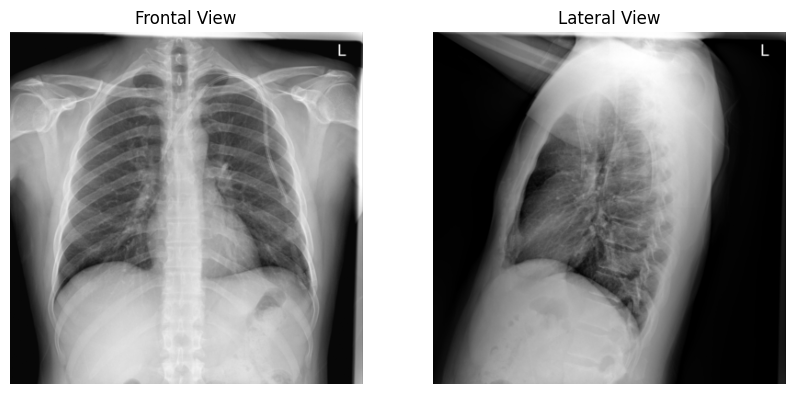

True Caption: The lungs appear clear. There are no suspicious pulmonary nodules or infiltrates. The heart and pulmonary XXXX appear normal. The pleural spaces are clear. Mediastinal contours are normal. There is a left-sided tunneled catheter, the distal tip at the mid superior XXXX XXXX level.
Pred Caption: Heart size within normal limits, stable mediastinal contours, and hilar contours. No alveolar focal alveolar consolidation, no definite pleural effusion seen. No typical findings of pulmonary edema.
--------------------------------------------------
Accuracy su tutto il set di validazione: 24.91%

Accuratezze per classe:
Classe 0: 38.54% (79/205)
Classe 1: 8.29% (18/217)
Classe 2: 14.71% (5/34)
Classe 3: 41.30% (19/46)
Classe 4: 34.09% (15/44)

Dettagli predizioni:
Campione 1: Classe vera = 4, Classe predetta = 4
Campione 2: Classe vera = 1, Classe predetta = 2
Campione 3: Classe vera = 1, Classe predetta = 4
Campione 4: Classe vera = 0, Classe predetta = 0
Campione 5: Classe vera 

In [11]:
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE_DATALOADERS,
    collate_fn=collate_fn
)
test_loader = WrappedDataLoader(test_loader)

warnings.filterwarnings("ignore", category=UserWarning, module="transformers")
logging.getLogger("transformers").setLevel(logging.ERROR)

def calculate_bleu(pred_ids, ref_ids, tokenizer):
    pred_tokens = tokenizer.convert_ids_to_tokens(pred_ids)
    ref_tokens = tokenizer.convert_ids_to_tokens(ref_ids)

    if not pred_tokens or not ref_tokens:
        return (0.0, 0.0, 0.0, 0.0)

    smoothing = SmoothingFunction().method1
    bleu1 = sentence_bleu([ref_tokens], pred_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothing)
    bleu2 = sentence_bleu([ref_tokens], pred_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
    bleu3 = sentence_bleu([ref_tokens], pred_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing)
    bleu4 = sentence_bleu([ref_tokens], pred_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing)

    return bleu1, bleu2, bleu3, bleu4

def calculate_rouge_l(predicted_text, reference_text):
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    score = scorer.score(reference_text, predicted_text)
    return score['rougeL'].fmeasure

def test_model(model, test_loader, tokenizer):
    model.eval()
    total_bleu1 = total_bleu2 = total_bleu3 = total_bleu4 = 0
    total_rouge_l = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            gen_ids = model.generate_report(
                front_image=batch['front_pixel_values'],
                lateral_img=batch['lateral_pixel_values'],
                device=device,
                temperature=1.0,
                top_k=50
            )

            for pred_ids, ref_ids in zip(gen_ids, batch['input_ids_caption']):
                bleu1, bleu2, bleu3, bleu4 = calculate_bleu(pred_ids.tolist(), ref_ids.tolist(), tokenizer)
                total_bleu1 += bleu1
                total_bleu2 += bleu2
                total_bleu3 += bleu3
                total_bleu4 += bleu4

                predicted_text = tokenizer.decode(pred_ids.tolist(), skip_special_tokens=True)
                reference_text = tokenizer.decode(ref_ids.tolist(), skip_special_tokens=True)
                rouge_l_score = calculate_rouge_l(predicted_text, reference_text)
                total_rouge_l += rouge_l_score

    dataset_size = len(test_loader.dataset)
    metrics = {
        'bleu1': total_bleu1 / dataset_size,
        'bleu2': total_bleu2 / dataset_size,
        'bleu3': total_bleu3 / dataset_size,
        'bleu4': total_bleu4 / dataset_size,
        'rouge_l': total_rouge_l / dataset_size
    }

    print("\nTest Results:")
    print(f"BLEU-1 Score: {metrics['bleu1']:.4f}")
    print(f"BLEU-2 Score: {metrics['bleu2']:.4f}")
    print(f"BLEU-3 Score: {metrics['bleu3']:.4f}")
    print(f"BLEU-4 Score: {metrics['bleu4']:.4f}")
    print(f"ROUGE-L Score: {metrics['rouge_l']:.4f}")

    return metrics

def visualize_predictions(model, test_loader, tokenizer, num_images=2):
    import matplotlib.pyplot as plt
    model.eval()
    visualizations_shown = 0

    with torch.no_grad():
        for batch in test_loader:
            gen_ids = model.generate_report(
                front_image=batch['front_pixel_values'],
                lateral_img=batch['lateral_pixel_values'],
                device=device,
                temperature=1.0,
                top_k=50
            )

            for i in range(len(gen_ids)):
                if visualizations_shown >= num_images:
                    return

                pred_caption = tokenizer.decode(gen_ids[i].tolist(), skip_special_tokens=True)
                true_caption = tokenizer.decode(batch['input_ids_caption'][i].tolist(), skip_special_tokens=True)
                
                plt.figure(figsize=(10, 5))

                plt.subplot(1, 2, 1)
                plt.imshow(batch['front_pixel_values'][i].cpu().permute(1, 2, 0))
                plt.axis('off')
                plt.title('Frontal View')

                plt.subplot(1, 2, 2)
                plt.imshow(batch['lateral_pixel_values'][i].cpu().permute(1, 2, 0))
                plt.axis('off')
                plt.title('Lateral View')

                plt.show()
                print(f"True Caption: {true_caption}")
                print(f"Pred Caption: {pred_caption}")
                print('-' * 50)

                visualizations_shown += 1

def evaluate_predictions_full(model, val_loader, num_class_pred=num_class_pred):
    import torch
    import numpy as np
    from sklearn.metrics import confusion_matrix
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    correct_predictions = 0
    total_predictions = 0
    class_correct = torch.zeros(num_class_pred, dtype=torch.int32)
    class_total = torch.zeros(num_class_pred, dtype=torch.int32)
    all_predictions = []
    
    with torch.no_grad():
        for batch in val_loader:
            front_image = batch['front_pixel_values']
            lateral_image = batch['lateral_pixel_values']
            labels = torch.argmax(batch['categories'], dim=1)
            
            outputs = model(
                front_image=front_image,
                lateral_img=lateral_image,
                input_ids_caption=batch['input_ids_caption'],
                attention_mask_caption=batch['attention_mask_caption'],
                calc_caption_loss=False,
                calc_vae_loss=False
            )
            logits = outputs["classification_logits"]
            predicted_labels = torch.argmax(logits, dim=1)

            for true_label, pred_label in zip(labels.tolist(), predicted_labels.tolist()):
                all_predictions.append((true_label, pred_label))
            
            correct_predictions += (predicted_labels == labels).sum().item()
            total_predictions += labels.size(0)
            
            for class_label in range(num_class_pred):
                class_correct[class_label] += ((predicted_labels == class_label) &
                                               (labels == class_label)).sum().item()
                class_total[class_label] += (labels == class_label).sum().item()
    
    accuracy = 100.0 * correct_predictions / total_predictions
    print(f"Accuracy su tutto il set di validazione: {accuracy:.2f}%")
    
    print("\nAccuratezze per classe:")
    for class_label in range(num_class_pred):
        if class_total[class_label] > 0:
            class_accuracy = 100.0 * class_correct[class_label] / class_total[class_label]
            print(f"Classe {class_label}: {class_accuracy:.2f}% "
                  f"({class_correct[class_label]}/{class_total[class_label]})")
        else:
            print(f"Classe {class_label}: Nessun campione presente.")
    
    print("\nDettagli predizioni:")
    for i, (true_label, pred_label) in enumerate(all_predictions):
        print(f"Campione {i + 1}: Classe vera = {true_label}, Classe predetta = {pred_label}")

    return accuracy

metrics = test_model(model, test_loader, tokenizer)
visualize_predictions(model, test_loader, tokenizer, num_images=1)

accuracy = evaluate_predictions_full(model, test_loader)
print(f"Accuracy Finale: {accuracy:.2f}%")

print("fine evaluate predictions full e text loss")


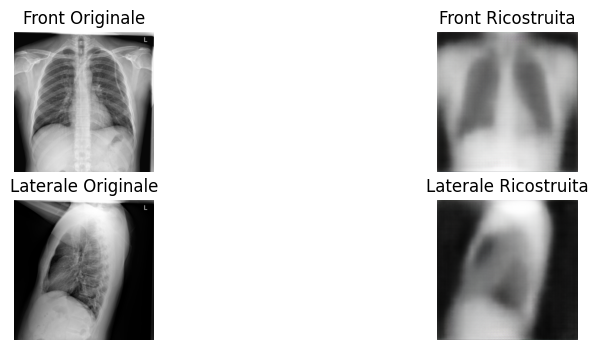

fine ricostruzione VAE di esempio


In [12]:
def visualize_vae_reconstruction(model, dataset, idx=0):
    model.eval()
    sample = dataset[idx]
    front_img = sample['front_pixel_values'].unsqueeze(0).to(device)
    lat_img   = sample['lateral_pixel_values'].unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(
            front_image=front_img,
            lateral_img=lat_img,
            calc_vae_loss=True
        )
        recons_front = outputs['recons_front']
        recons_lateral = outputs['recons_lateral']

    # Visualizzazione
    plt.figure(figsize=(10, 4))

    # Frontale
    plt.subplot(2, 2, 1)
    plt.imshow(front_img.squeeze(0).permute(1, 2, 0).cpu().numpy())
    plt.title("Front Originale")
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(recons_front.squeeze(0).permute(1, 2, 0).cpu().numpy())
    plt.title("Front Ricostruita")
    plt.axis('off')

    # Laterale
    plt.subplot(2, 2, 3)
    plt.imshow(lat_img.squeeze(0).permute(1, 2, 0).cpu().numpy())
    plt.title("Laterale Originale")
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(recons_lateral.squeeze(0).permute(1, 2, 0).cpu().numpy())
    plt.title("Laterale Ricostruita")
    plt.axis('off')

    plt.show()

visualize_vae_reconstruction(model, test_ds, idx=0)
print("fine ricostruzione VAE di esempio")
